Preprocessing

In [19]:
import pandas as pd  
import numpy as np


In [20]:
Data = pd.read_csv("adults.csv")


y_raw = Data['hours-per-week']
x_raw = Data
x_raw.drop('education-num', axis=1, inplace=True)
x_raw.drop('income', axis=1, inplace=True)
print(x_raw.shape)
print(y_raw.shape)


(48842, 13)
(48842,)


In [21]:
# x_raw = x_raw.replace("?", np.nan)
# x_raw[pd.isnull(x_raw).any(axis=1)].shape
# rows_with_missing_values = x_raw[pd.isnull(x_raw).any(axis=1)]

# x_raw.dropna(inplace=True)
# x_raw.drop('education-num', axis=1, inplace=True)
# y_raw = y_raw.drop(rows_with_missing_values.index)


In [22]:
# x = pd.DataFrame(x_raw)
# y = pd.DataFrame(y_raw)
# x_names = x.columns.tolist()
# x_names = np.array(x_names)
# y_names = y.columns.tolist()
x = x_raw
y = y_raw

In [23]:
#print(x[10:60])
print(x['workclass'][x['workclass'] == '?'])

x['workclass'], value = pd.factorize(x_raw['workclass'])
print("1",value)
x['education'], value = pd.factorize(x_raw['education'])
print("2",value)
x['marital-status'], value = pd.factorize(x_raw['marital-status'])
print("3",value)
x['occupation'], value = pd.factorize(x_raw['occupation'])
print("4",value)
x['relationship'], value = pd.factorize(x_raw['relationship'])
print("5",value)
x['race'], value = pd.factorize(x_raw['race'])
print("6",value)
x['sex'], value = pd.factorize(x_raw['sex'])
print("7",value)
x['native-country'], value = pd.factorize(x_raw['native-country'])
print("9",value)


#print(x)

Series([], Name: workclass, dtype: object)
1 Index([' State-gov', ' Self-emp-not-inc', ' Private', ' Federal-gov',
       ' Local-gov', ' ?', ' Self-emp-inc', ' Without-pay', ' Never-worked'],
      dtype='object')
2 Index([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th', ' Some-college',
       ' Assoc-acdm', ' Assoc-voc', ' 7th-8th', ' Doctorate', ' Prof-school',
       ' 5th-6th', ' 10th', ' 1st-4th', ' Preschool', ' 12th'],
      dtype='object')
3 Index([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'],
      dtype='object')
4 Index([' Adm-clerical', ' Exec-managerial', ' Handlers-cleaners',
       ' Prof-specialty', ' Other-service', ' Sales', ' Craft-repair',
       ' Transport-moving', ' Farming-fishing', ' Machine-op-inspct',
       ' Tech-support', ' ?', ' Protective-serv', ' Armed-Forces',
       ' Priv-house-serv'],
      dtype='object')
5 Index([' Not-in-family', ' Husband', '

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x['age'] = scaler.fit_transform(x[['age']])
x['fnlwgt'] = scaler.fit_transform(x[['fnlwgt']])
x['capital-gain'] = scaler.fit_transform(x[['capital-gain']])
x['capital-loss'] = scaler.fit_transform(x[['capital-loss']])

y = scaler.fit_transform(y.values.reshape(-1, 1))



RandomForest


In [25]:
print(type(x))

<class 'pandas.core.frame.DataFrame'>


In [26]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [27]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = []
mae = []
r2 = []

mean_mse = []
mean_mae = []
mean_r2 = []

for i in range(2,100):
    for train_index, test_index in kf.split(x):
        x_train = x.loc[train_index]
        x_test = x.loc[test_index]
        y_train = y[train_index]
        y_test = y[test_index]

        model = RandomForestRegressor(n_estimators=i, random_state=42,n_jobs=-1)

        # 擬合模型
        model.fit(x_train, y_train.ravel())

        pred_test = model.predict(x_test)

        mae.append(mean_absolute_error(y_test, pred_test))
        mse.append(mean_squared_error(y_test, pred_test))
        r2.append(r2_score(y_test, pred_test))

        # print("Mean Absolute Error: " ,mean_absolute_error(y_test, pred_test))
        # print("Mean Squared Error: " ,mean_squared_error(y_test, pred_test))
        # print("R2 Score: " ,r2_score(y_test, pred_test))

        # print("Train Index:", train_index)
        # print("Test Index:", test_index)
        # print("-----")

    # print("Mean Absolute Error:", np.mean(mae))
    # print("Mean Squared Error:", np.mean(mse))
    # print("R2 Score:", np.mean(r2))
    mean_mae.append(np.mean(mae))
    mean_mse.append(np.mean(mse))
    mean_r2.append(np.mean(r2))
    if (i%10) == 0: print(i,"/ 100")
print("Best Mean Absolute Error:", np.min(mae))
print("Best Mean Squared Error:", np.min(mse))
print("Best R2 Score:", np.min(r2))

10 / 100
20 / 100
30 / 100
40 / 100
50 / 100
60 / 100
70 / 100
80 / 100
90 / 100
Best Mean Absolute Error: 1.566965882298206e-06
Best Mean Squared Error: 3.4806960492684722e-09
Best R2 Score: 0.9999874813346841


97
97
97


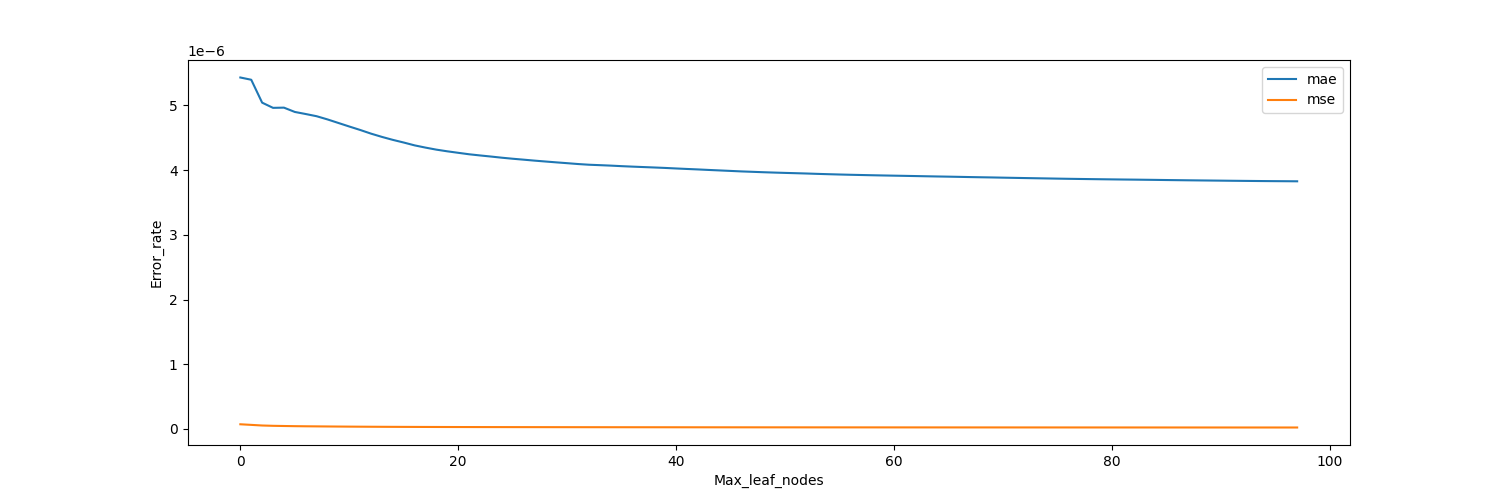

In [38]:
print(np.argmax(mean_r2))
print(np.argmin(mean_mae))
print(np.argmin(mean_mse))
import matplotlib.pyplot as plt
%matplotlib widget
fig = plt.figure(figsize=(15,5))
plt.xlabel('Max_leaf_nodes')
plt.ylabel("Error_rate")
plt.plot(mean_mae, label='mae')
plt.plot(mean_mse, label='mse')
#plt.plot(mean_r2, label='r2')
plt.legend()
plt.show()

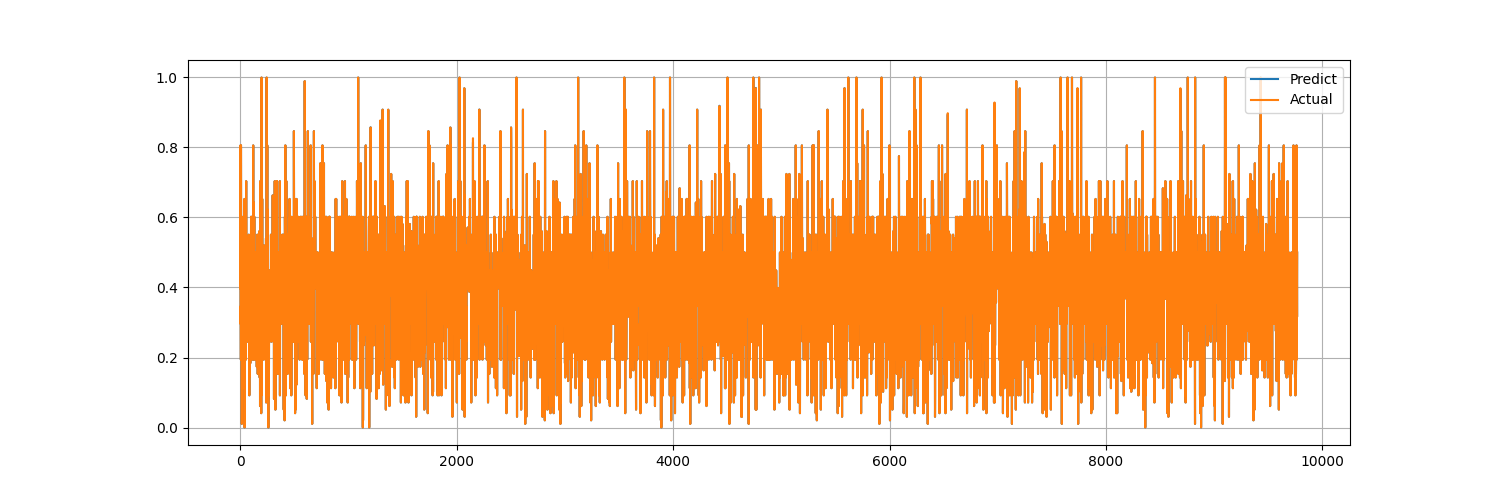

In [32]:
import matplotlib.pyplot as plt

# for i in range(len(y_test)):
#     print(pred_test[i],y_test[i])

fig = plt.figure(figsize=(15,5))
plt.plot(pred_test,label = 'Predict')
plt.plot(np.array(y_test),label = 'Actual')
plt.grid()
plt.legend()
plt.show()